In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [2]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import Perceptron

In [3]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dropout

from tensorflow.keras.utils import to_categorical

In [4]:
df_tr= pd.read_csv('train.csv')
df_te = pd.read_csv('test.csv')

In [5]:
df_tr.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

In [6]:
df_train = pd.read_csv('mnist_train.csv', names=['label'] + [f'pixel{i}' for i in range(784)])
df_test = pd.read_csv('mnist_test.csv', names=['label'] + [f'pixel{i}' for i in range(784)])

In [7]:
df_test.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
df_test.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df_train.shape

(60000, 785)

In [10]:
df_train.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

In [11]:
df_train.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

# Preprocess

In [12]:
X_train = df_train.drop('label', axis=1).values
y_train = df_train['label'].values
X_test = df_test.drop('label', axis=1).values
y_test = df_test['label'].values

In [13]:
X_train_img = X_train.reshape(-1,28,28)
X_test_img = X_test.reshape(-1,28,28)

In [14]:
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [15]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [16]:
perceptron.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
percp_history = perceptron.fit(
    X_train_img,
    y_train_cat,
    validation_data = [X_test_img,y_test_cat],
    epochs = 5,
    batch_size = 32, # must be power of 2
    verbose = 1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 485us/step - accuracy: 0.8394 - loss: 9.9646 - val_accuracy: 0.8742 - val_loss: 6.8948
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 427us/step - accuracy: 0.8786 - loss: 6.0664 - val_accuracy: 0.8927 - val_loss: 5.5114
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 409us/step - accuracy: 0.8843 - loss: 5.6157 - val_accuracy: 0.8835 - val_loss: 5.8450
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 415us/step - accuracy: 0.8852 - loss: 5.4805 - val_accuracy: 0.8734 - val_loss: 6.3239
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 500us/step - accuracy: 0.8858 - loss: 5.3691 - val_accuracy: 0.8925 - val_loss: 5.4548


In [18]:
acc_precp = perceptron.evaluate(X_test_img,y_test_cat, verbose=0)[1]
acc_precp

0.8924999833106995

In [19]:
#ANN

ann_model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [20]:
ann_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [21]:
ann_history = ann_model.fit(
    X_train_img,
    y_train_cat,
    validation_data = [X_test_img,y_test_cat],
    epochs = 5,
    batch_size = 32, # must be power of 2
    verbose = 1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 976us/step - accuracy: 0.8675 - loss: 1.9458 - val_accuracy: 0.9165 - val_loss: 0.3808
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 887us/step - accuracy: 0.9301 - loss: 0.2886 - val_accuracy: 0.9399 - val_loss: 0.2253
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 844us/step - accuracy: 0.9440 - loss: 0.2079 - val_accuracy: 0.9519 - val_loss: 0.1797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 857us/step - accuracy: 0.9544 - loss: 0.1675 - val_accuracy: 0.9456 - val_loss: 0.2122
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 864us/step - accuracy: 0.9595 - loss: 0.1413 - val_accuracy: 0.9578 - val_loss: 0.1658


In [22]:
acc_ann = ann_model.evaluate(X_test_img,y_test_cat, verbose=0)[1]
acc_ann

0.9577999711036682

In [23]:
X_train_cnn = X_train.reshape(-1,28,28,1)
X_test_cnn = X_test.reshape(-1,28,28,1)

In [24]:
# CNN

cnn_model = Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])


In [25]:
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [26]:
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_cat,
    validation_data = [X_test_cnn,y_test_cat],
    epochs = 5,
    batch_size = 32, # must be power of 2
    verbose = 1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8575 - loss: 0.5751 - val_accuracy: 0.9768 - val_loss: 0.0789
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9545 - loss: 0.1589 - val_accuracy: 0.9820 - val_loss: 0.0566
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9668 - loss: 0.1158 - val_accuracy: 0.9838 - val_loss: 0.0603
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9711 - loss: 0.1003 - val_accuracy: 0.9858 - val_loss: 0.0486
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9762 - loss: 0.0825 - val_accuracy: 0.9880 - val_loss: 0.0543


In [27]:
acc_cnn = cnn_model.evaluate(X_test_cnn,y_test_cat, verbose=0)[1]
acc_cnn

0.9879999756813049

In [28]:

def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()

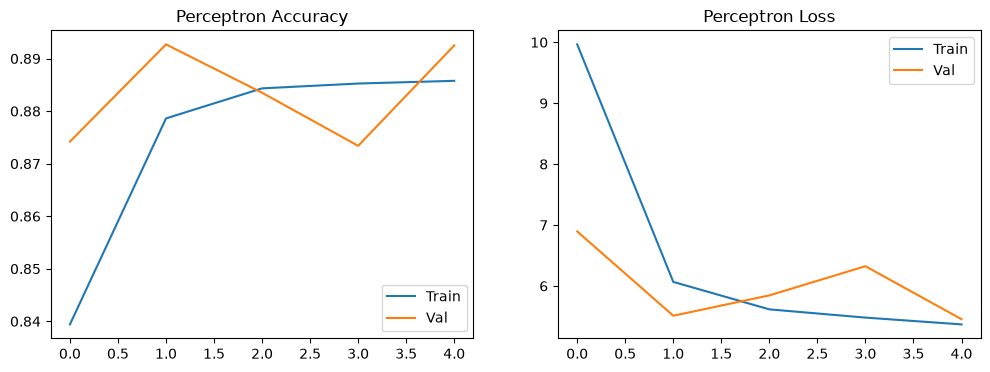

In [29]:
plot_training(percp_history, "Perceptron")

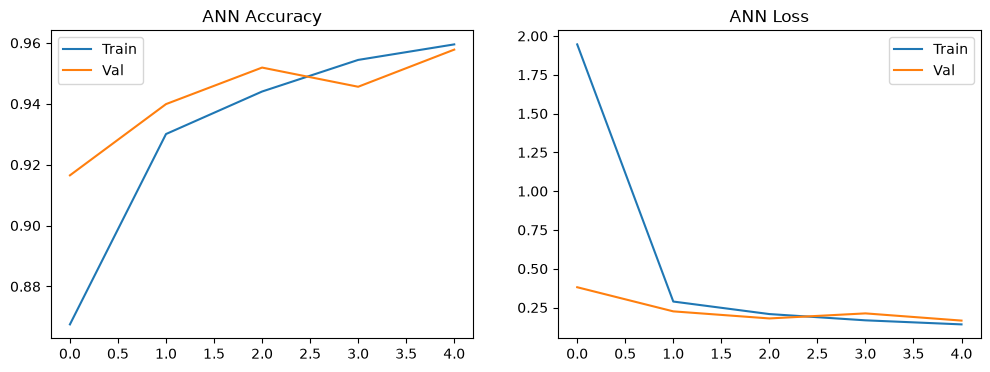

In [30]:
plot_training(ann_history, "ANN")

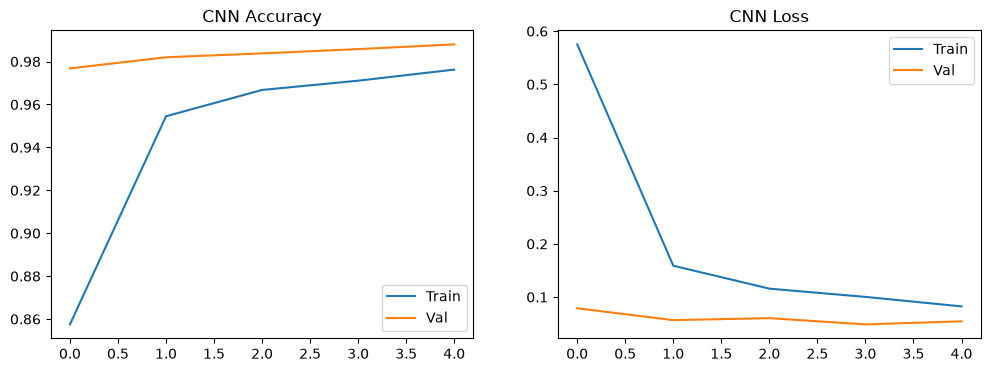

In [31]:
plot_training(cnn_history, "CNN")

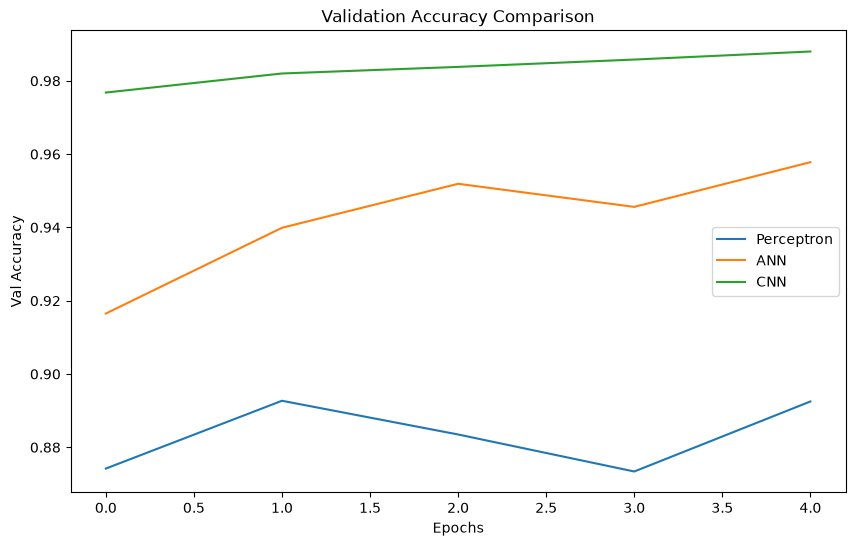

In [32]:

plt.figure(figsize=(10,6))
plt.plot(percp_history.history['val_accuracy'], label="Perceptron")
plt.plot(ann_history.history['val_accuracy'], label="ANN")
plt.plot(cnn_history.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

In [33]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


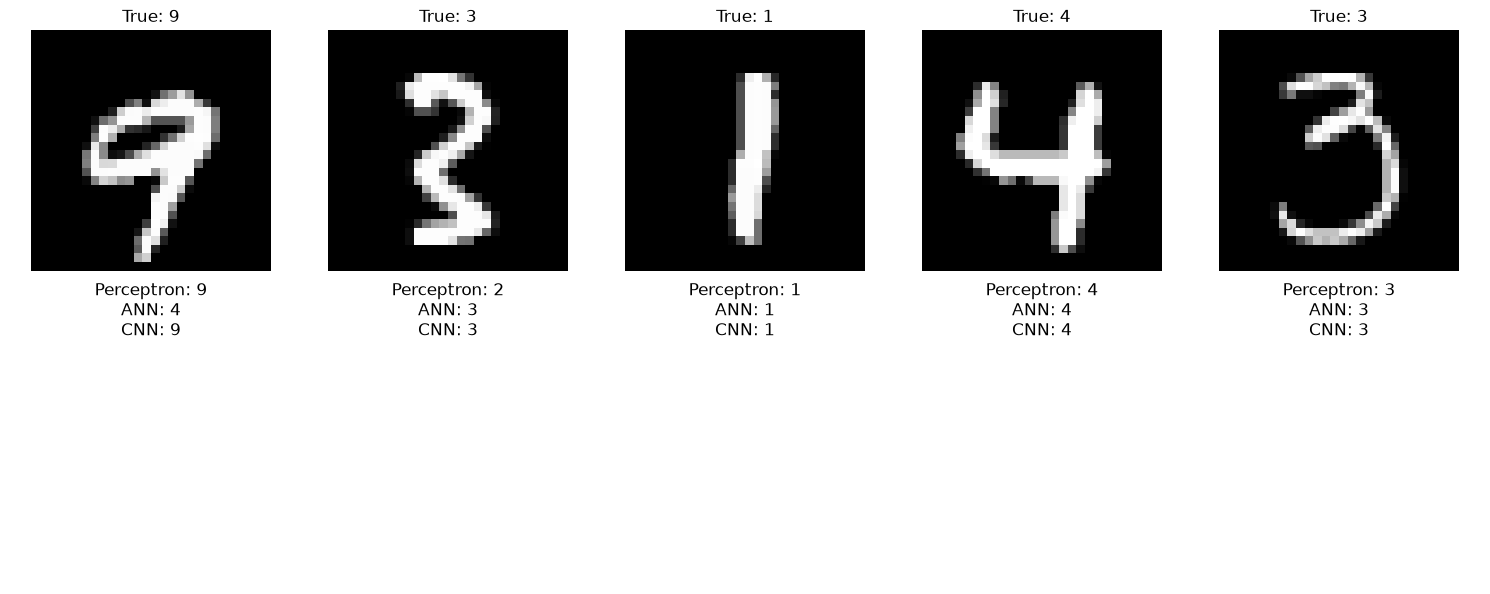

In [34]:
show_side_by_side([perceptron, ann_model, cnn_model], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)